--- Model Results ---
Mean Absolute Error: 1.09 grade points
R-Squared Score: 0.85


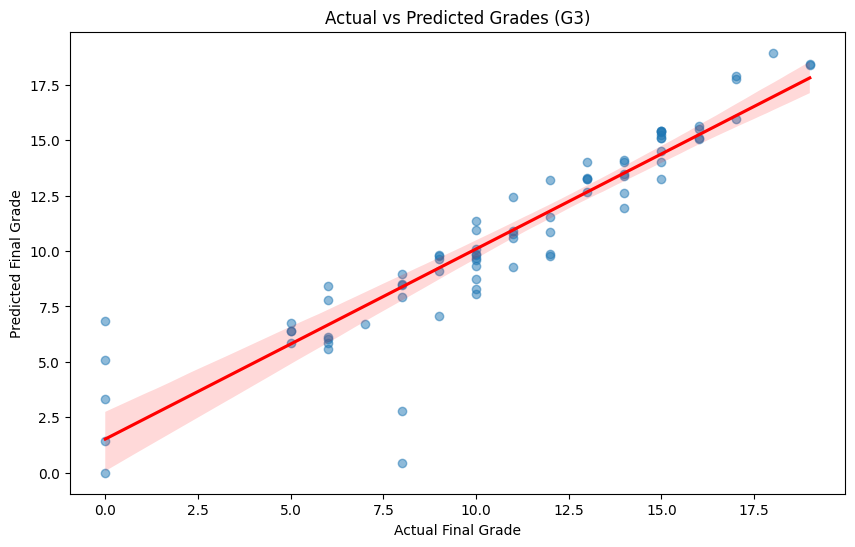

Clean Prediction for G3: 14.24


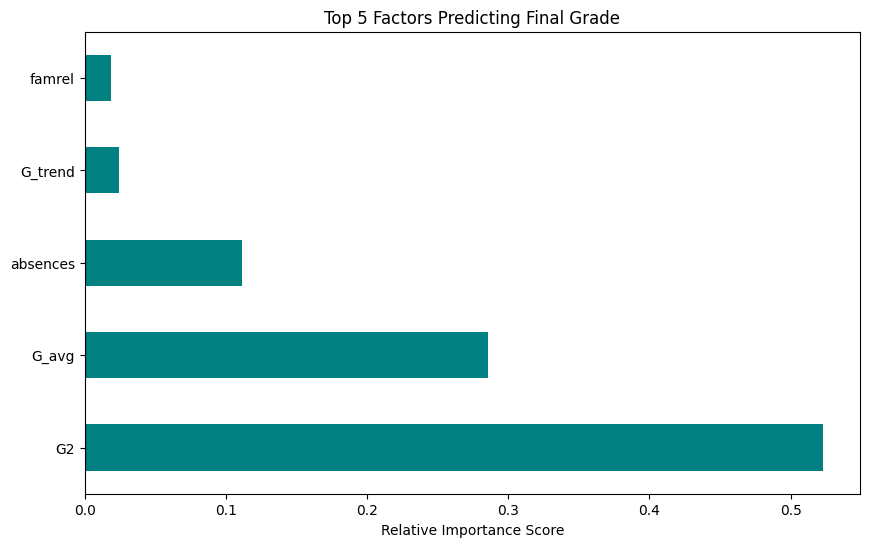

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- STEP 1: LOAD DATA ---
# Use sep=';' because this specific Kaggle CSV uses semicolons
df = pd.read_csv('student-mat.csv', sep=';')

# --- STEP 2: DATA MINING & FEATURE ENGINEERING ---
# We create a 'Trend' feature to see if the student is improving or declining
df['G_trend'] = df['G2'] - df['G1']
# Calculate the academic momentum
df['G_avg'] = (df['G1'] + df['G2']) / 2

# Select our Features (Including the grades we kept this time)
features = ['G1', 'G2', 'G_trend', 'G_avg', 'absences', 'studytime', 'failures', 'famrel', 'freetime']
X = df[features]
y = df['G3']

# --- STEP 3: SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 4: TRAIN THE MODEL ---
# Random Forest handles the relationship between G1, G2, and G3 perfectly
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- STEP 5: EVALUATION ---
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- Model Results ---")
print(f"Mean Absolute Error: {mae:.2f} grade points")
print(f"R-Squared Score: {r2:.2f}")

# --- STEP 6: VISUALIZE PATTERNS ---
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=predictions, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Actual vs Predicted Grades (G3)')
plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')
plt.show()

def predict_student_performance(g1, g2, absences, studytime):
    # 1. Create the engineered features
    trend = g2 - g1
    avg = (g1 + g2) / 2

    # 2. Create a dictionary with ALL features used during .fit()
    # Ensure the names and order match 'features' list from earlier
    data_dict = {
        'G1': [g1],
        'G2': [g2],
        'G_trend': [trend],
        'G_avg': [avg],
        'absences': [absences],
        'studytime': [studytime],
        'failures': [0], # Defaulting to 0 for a test
        'famrel': [4],   # Defaulting to 4 (good)
        'freetime': [3]  # Defaulting to 3 (average)
    }

    # 3. Convert to DataFrame to keep Scikit-Learn happy
    input_df = pd.DataFrame(data_dict)

    result = model.predict(input_df)
    return round(result[0], 2)

print(f"Clean Prediction for G3: {predict_student_performance(10, 14, 2, 4)}")

# Extract importance
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)

# Plot
plt.figure(figsize=(10,6))
feat_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Top 5 Factors Predicting Final Grade')
plt.xlabel('Relative Importance Score')
plt.show()